# **Problem Definition**

- Problem being solved - Early detection of type 2 diabetes.
- Multi Class Classification problem.
- Target variable (Diabetes_012) - 0 = no diabetes, 1 = prediabetes, 2 = diabetes

# 1.Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTENC

# **Data Collection**

In [2]:
df = pd.read_csv("diabetes_012_health_indicators.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [3]:
df.tail()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0,1,1,1,45,0,0,0,0,1,...,1,0,3,0,5,0,1,5,6,7
253676,2,1,1,1,18,0,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,0,0,0,1,28,0,0,0,1,1,...,1,0,1,0,0,0,0,2,5,2
253678,0,1,0,1,23,0,0,0,0,1,...,1,0,3,0,0,0,1,7,5,1
253679,2,1,1,1,25,0,0,1,1,1,...,1,0,2,0,0,0,0,9,6,2


# **Data Cleaning and Preprocessing**

In [4]:
df.shape

(253680, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-null  int64


In [6]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [7]:
# dropping irrelevant columns
df.drop(columns=["Smoker", "HvyAlcoholConsump", "CholCheck", "Fruits", "Veggies", "AnyHealthcare", "NoDocbcCost", "Sex"], inplace=True)

In [8]:
df.head()

,Diabetes_012,HighBP,HighChol,BMI,Stroke,HeartDiseaseorAttack,PhysActivity,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Education,Income
0,0,1,1,40,0,0,0,5,18,15,1,9,4,3
1,0,0,0,25,0,0,1,3,0,0,0,7,6,1
2,0,1,1,28,0,0,0,5,30,30,1,9,4,8
3,0,1,0,27,0,0,1,2,0,0,0,11,3,6
4,0,1,1,24,0,0,1,2,3,0,0,11,5,4


- Smoker and HvyAlcoholConsump - While relevant to overall lifestyle, their direct mathematical correlation with distinguishing prediabetes specifically is very noisy in BRFSS survey data.
- CholCheck - Over $95\%$ of survey participants report having had a cholesterol check in the last 5 years, making this column almost entirely redundant with HighChol.
- Fruits and Veggies - Binary answers like "eating fruit 1+ times a day" do not contain enough statistical nuance to distinguish prediabetes from diabetes.
- AnyHealthcare and NoDocbcCost - Extremely low variance across respondents; they add noise rather than useful predictive signals.
- Sex - Biological sex shows very weak correlation boundaries across the 3 metabolic states compared to BMI, blood pressure, and age.

In [9]:
# number of 100% exact duplicate rows
df.duplicated().sum()

np.int64(65589)

In [10]:
# view actual duplicate rows - counts all rows involved in duplicates (original copies + redundant copies)
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,Diabetes_012,HighBP,HighChol,BMI,Stroke,HeartDiseaseorAttack,PhysActivity,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Education,Income
151777,0,0,0,14,0,0,1,2,0,0,0,6,4,8
237828,0,0,0,14,0,0,1,2,0,0,0,6,4,8
109681,0,0,0,16,0,0,1,1,2,0,0,5,6,8
192034,0,0,0,16,0,0,1,1,2,0,0,5,6,8
68962,0,0,0,16,0,0,1,2,0,0,0,13,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175049,2,1,1,42,0,0,1,3,0,0,0,10,4,5
167411,2,1,1,43,0,0,1,3,0,1,0,7,6,8
226458,2,1,1,43,0,0,1,3,0,1,0,7,6,8
166021,2,1,1,45,0,0,0,3,0,0,0,9,6,6


In [11]:
# 1. Define feature columns vs target column
feature_cols = [col for col in df.columns if col != 'Diabetes_012']

# 2. Compute key duplicate & target statistics
total_rows = len(df)
full_dups_count = df.duplicated().sum()
unique_feature_patterns = df.groupby(feature_cols).ngroups

# Identify conflicting vs consistent feature profiles
target_counts = df.groupby(feature_cols)['Diabetes_012'].nunique()
conflicting_patterns = (target_counts > 1).sum()
consistent_patterns = (target_counts == 1).sum()

# 3. Compute probability calibration impact
pattern_sizes = df.groupby(feature_cols).size()
dup_patterns_count = (pattern_sizes > 1).sum()

print("=" * 65)
print("              EVIDENCE: WHY YOU SHOULD NOT DROP DUPLICATES           ")
print("=" * 65)

print(f"\n1. POPULATION REPRESENTATION")
print(f"   • Total Survey Respondents: {total_rows:,}")
print(f"   • Exact Duplicate Rows: {full_dups_count:,} ({(full_dups_count/total_rows)*100:.2f}% of data)")
print(f"   • Unique Answer Profiles: {unique_feature_patterns:,}")
print(f"   --> IMPACT OF DROPPING: Dropping rows deletes {full_dups_count:,} real human responses")
print(f"       and flattens common demographic profiles to match rare ones.")

print(f"\n2. PRESERVING REAL-WORLD TARGET PROBABILITIES")
print(f"   • Feature Profiles with Identical Targets:  {consistent_patterns - (unique_feature_patterns - dup_patterns_count):,} patterns")
print(f"   • Feature Profiles with Conflicting Targets: {conflicting_patterns:,} patterns ({(conflicting_patterns/dup_patterns_count)*100:.1f}% of repeated patterns)")
print(f"   --> IMPACT OF DROPPING: Out of {dup_patterns_count:,} repeated profiles, {conflicting_patterns:,}")
print(f"       have mixed targets (e.g., 60% 'Yes' / 40% 'No'). Dropping duplicates destroys")
print(f"       these natural outcome ratios, making class probability estimation inaccurate.")

print(f"\n3. SUMMARY VERDICT")
print(f"   --> KEEP ALL ROWS. In survey datasets, identical rows represent real frequency")
print(f"       weights. Machine learning algorithms (XGBoost, Random Forest, Logistic Regression)")
print(f"       need these exact counts to learn calibrated probability outputs.")
print("=" * 65)

              EVIDENCE: WHY YOU SHOULD NOT DROP DUPLICATES           

1. POPULATION REPRESENTATION
   • Total Survey Respondents: 253,680
   • Exact Duplicate Rows: 65,589 (25.86% of data)
   • Unique Answer Profiles: 182,325
   --> IMPACT OF DROPPING: Dropping rows deletes 65,589 real human responses
       and flattens common demographic profiles to match rare ones.

2. PRESERVING REAL-WORLD TARGET PROBABILITIES
   • Feature Profiles with Identical Targets:  16,980 patterns
   • Feature Profiles with Conflicting Targets: 5,480 patterns (24.4% of repeated patterns)
   --> IMPACT OF DROPPING: Out of 22,460 repeated profiles, 5,480
       have mixed targets (e.g., 60% 'Yes' / 40% 'No'). Dropping duplicates destroys
       these natural outcome ratios, making class probability estimation inaccurate.

3. SUMMARY VERDICT
   --> KEEP ALL ROWS. In survey datasets, identical rows represent real frequency
       weights. Machine learning algorithms (XGBoost, Random Forest, Logistic Regression

# **Exploratory Data Analysis (EDA)**

In [12]:
# descriptive statistics of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
GenHlth,253680.0,2.511392,1.068477,1.0,2.0,2.0,3.0,5.0
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0


In [13]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'BMI', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'MentHlth',
       'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income'],
      dtype='str')

# Distribution of columns

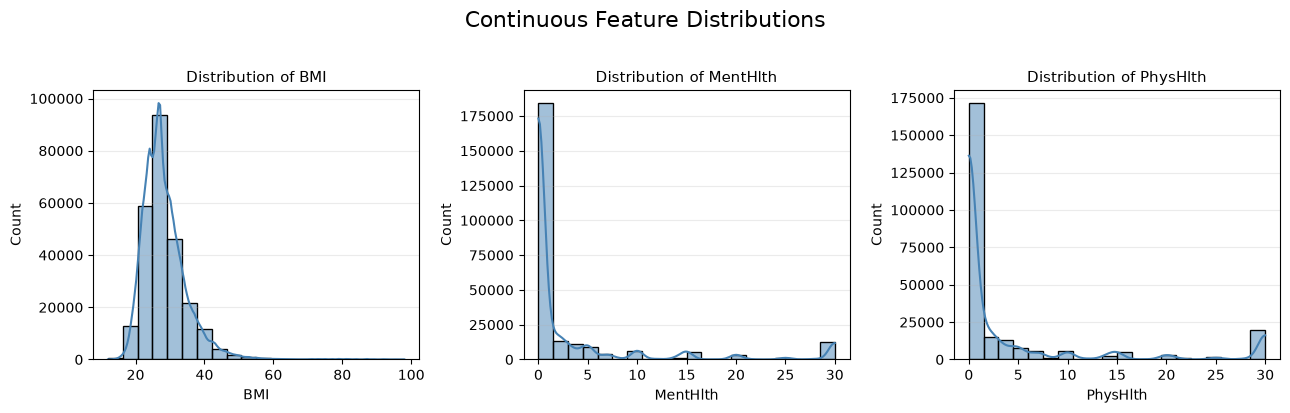

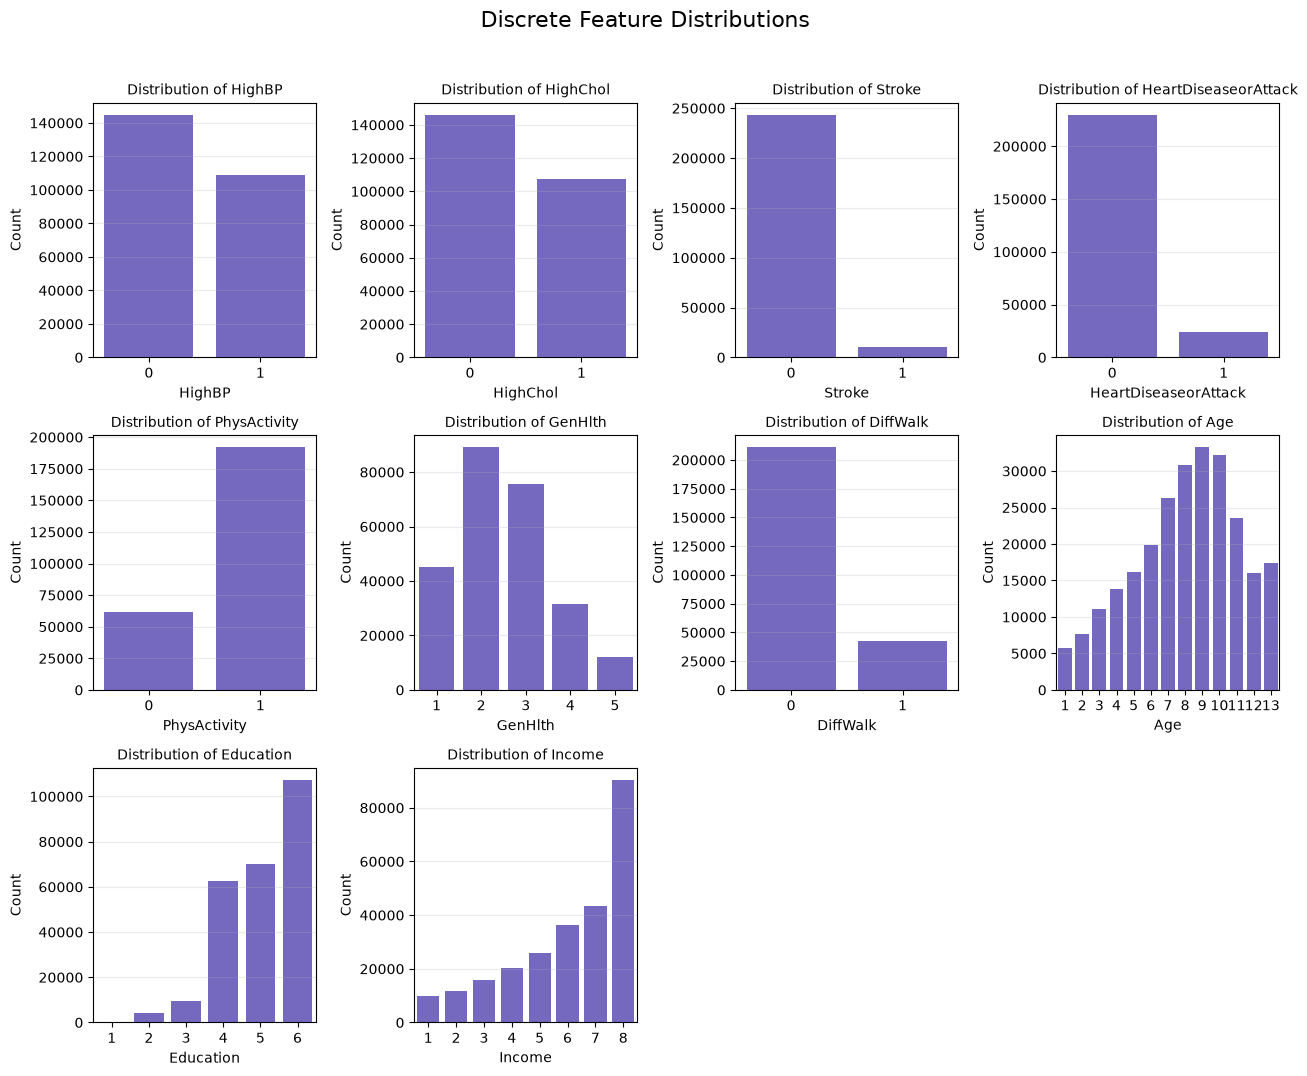

In [14]:
# Separate continuous numerical features from binary and ordinal categorical features.
numerical_features = ["BMI", "MentHlth", "PhysHlth"]
categorical_features = [
    col for col in feature_cols
    if col not in numerical_features
]

# Grid 1: distributions of continuous numerical features.
cols_per_row = 3
rows_needed = math.ceil(len(numerical_features) / cols_per_row)
fig, axes = plt.subplots(
    rows_needed,
    cols_per_row,
    figsize=(13, 4 * rows_needed),
    squeeze=False
)
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.25)

for ax in axes[len(numerical_features):]:
    ax.remove()

fig.suptitle("Continuous Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Grid 2: counts of binary and ordinal categorical features.
cols_per_row = 4
rows_needed = math.ceil(len(categorical_features) / cols_per_row)
fig, axes = plt.subplots(
    rows_needed,
    cols_per_row,
    figsize=(13, 3.5 * rows_needed),
    squeeze=False
)
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        color="slateblue"
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].grid(axis="y", alpha=0.25)

for ax in axes[len(categorical_features):]:
    ax.remove()

fig.suptitle("Discrete Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Insights

#### Numerical features
- BMI is concentrated around the middle values, with fewer observations at very low or very high BMI levels.
- MentHlth and PhysHlth are strongly right-skewed: most respondents report zero unhealthy days, while fewer report larger numbers of unhealthy days.
- The high values in MentHlth and PhysHlth should be investigated for potential outliers.

#### Categorical features
- Age, Education and Income show bars of how respondents are distributed across demographic categories.
- HeartDiseaseorAttack, have more observations with value 0 than 1.
- HighBP and HighChol still have substantial value-1 groups, showing that these conditions are common in the dataset as compared to Stroke and HeartDiseaseAttack.
- GenHlth is concentrated around better-to-average health ratings, while very poor health ratings are less common.


# Target Variable Analysis

is used when comparing two variables - mostly used in classification problems.

In [15]:
df["Diabetes_012"].value_counts()

Diabetes_012
0    213703
2     35346
1      4631
Name: count, dtype: int64

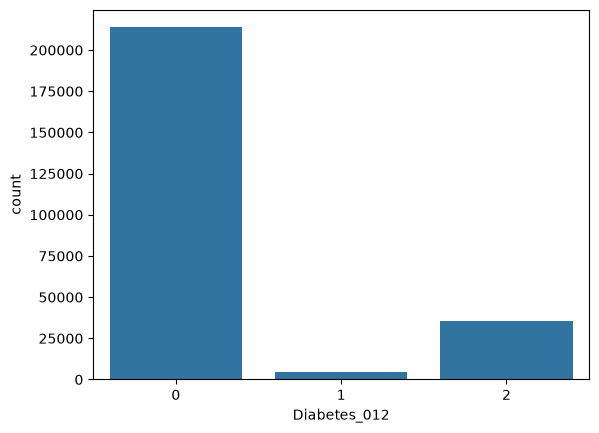

In [16]:
sns.countplot(data=df, x="Diabetes_012")
plt.show()

## Insights

The above shows that data is highly imbalanced with the majority of the respondents being the ones without diabetes, followed by ones with diabetes and lastly pre-diabetic respondents. This will be handled by using class_weights and SMOTE (handles imbalanced dataset by creating synthetic samples for the minority class) during the modellinng to balance it out and evaluate which performs better.

# Visualizing target variable (diabetes_012) against all features

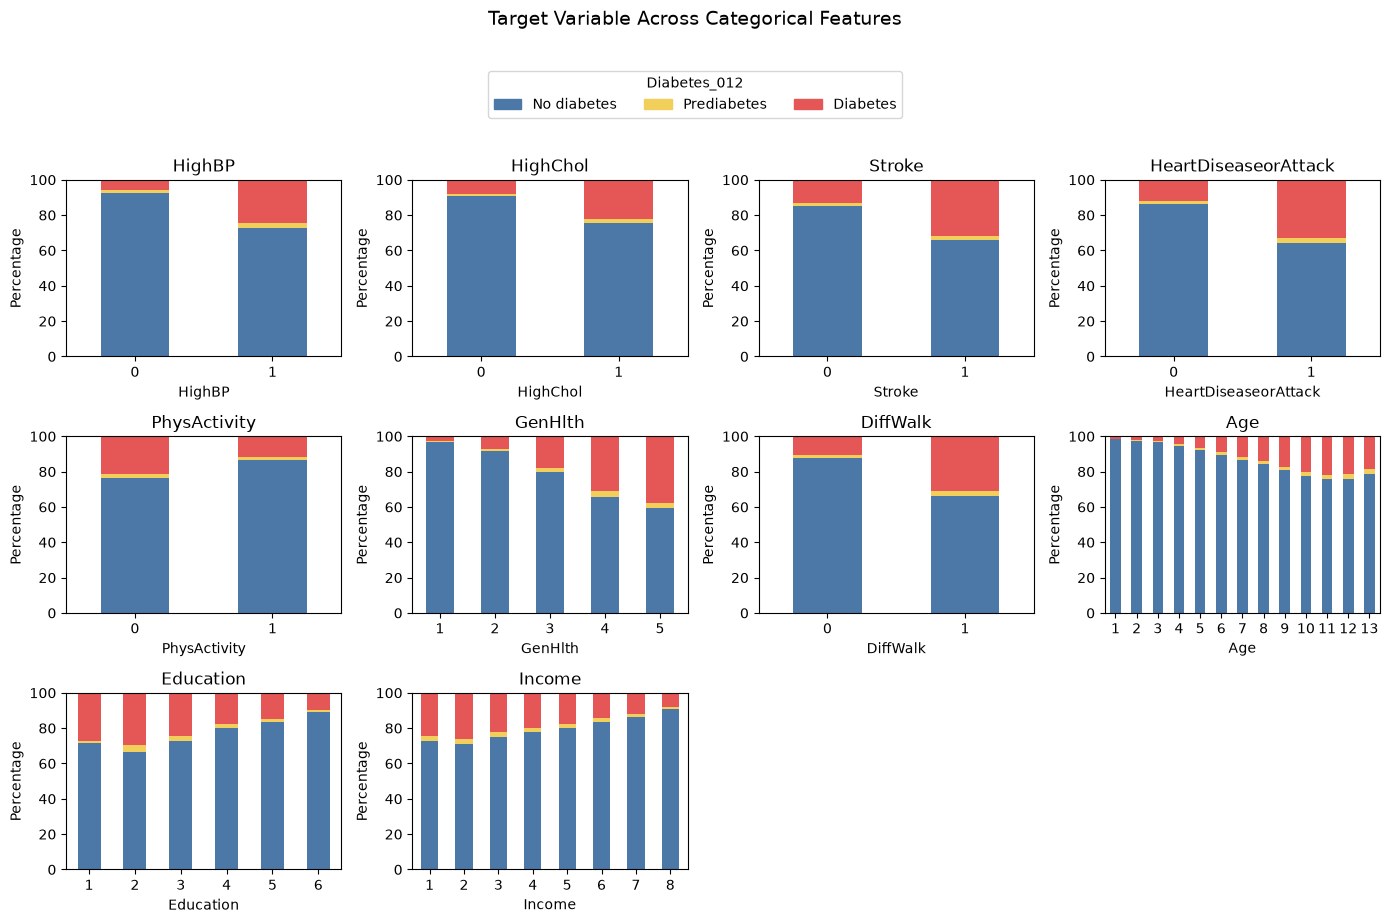

In [17]:
target_col = "Diabetes_012"
target_labels = {0: "No diabetes", 1: "Prediabetes", 2: "Diabetes"}
target_colors = {0: "#4C78A8", 1: "#F2CF5B", 2: "#E45756"}
continuous_features = ["BMI", "MentHlth", "PhysHlth"]
categorical_features = [col for col in feature_cols if col not in continuous_features]

fig, axes = plt.subplots(
    math.ceil(len(categorical_features) / 4), 4,
    figsize=(14, 9), squeeze=False
)
axes = axes.ravel()

for ax, feature in zip(axes, categorical_features):
    proportions = pd.crosstab(
        df[feature], df[target_col], normalize="index"
    ).reindex(columns=target_labels, fill_value=0) * 100
    proportions.plot(
        kind="bar", stacked=True, ax=ax,
        color=target_colors.values(), legend=False
    )
    ax.set(title=feature, xlabel=feature, ylabel="Percentage")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)

for ax in axes[len(categorical_features):]:
    ax.remove()

handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in target_colors.values()]
fig.legend(
    handles, target_labels.values(), title=target_col,
    ncol=3, loc="upper center", bbox_to_anchor=(0.5, 0.96)
)
fig.suptitle("Target Variable Across Categorical Features", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

## Insights

- **HighBP and HighChol:** Respondents answering yes show more diabetes and prediabetes, with fewer no-diabetes cases.
- **Stroke, HeartDiseaseorAttack and DiffWalk:** These conditions are linked to a larger diabetes share.
- **PhysActivity:** Inactive respondents show more diabetes; active respondents show more no diabetes.
- **GenHlth:** As self-rated health worsens, the diabetes share increases and the no-diabetes share falls.
- **Age:** Diabetes increases across older age groups, while no diabetes decreases.
- **Education and Income:** Lower levels show more diabetes; higher levels show more no diabetes.
- **Prediabetes:** This remains the smallest class across most feature categories.

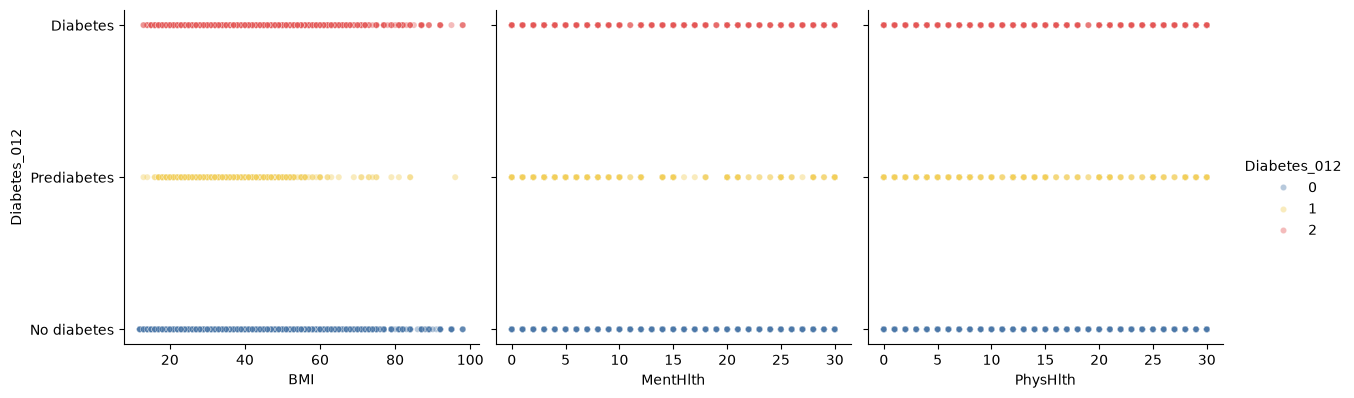

In [18]:
plot_df = df[continuous_features + [target_col]].copy()

grid = sns.pairplot(
    plot_df,
    x_vars=continuous_features,
    y_vars=[target_col],
    hue=target_col,
    palette=target_colors,
    height=4,
    plot_kws={"alpha": 0.4, "s": 20}
)

for ax in grid.axes.flat:
    ax.set_ylabel(target_col)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(target_labels.values())

plt.show()

## Insights

- **BMI:** The diabetes points extend more often toward higher BMI values, suggesting that increased body mass is associated with greater diabetes risk. However, all three classes overlap, so BMI alone cannot distinguish diabetes, prediabetes, and no diabetes.
- **MentHlth:** Most respondents report few mentally unhealthy days across all classes. The diabetes group is more dispersed toward higher values, suggesting that frequent mental-health problems may occur alongside diabetes, although the overlap is substantial.
- **PhysHlth:** No-diabetes respondents are concentrated near zero physically unhealthy days, while diabetes points appear more frequently across higher values. This suggests poorer physical health is associated with diabetes status.
- **Overall:** The plots show association rather than a clear boundary between classes. These features are likely more useful when combined with factors such as GenHlth, HighBP, Age, and DiffWalk.

# Correlation Heatmap

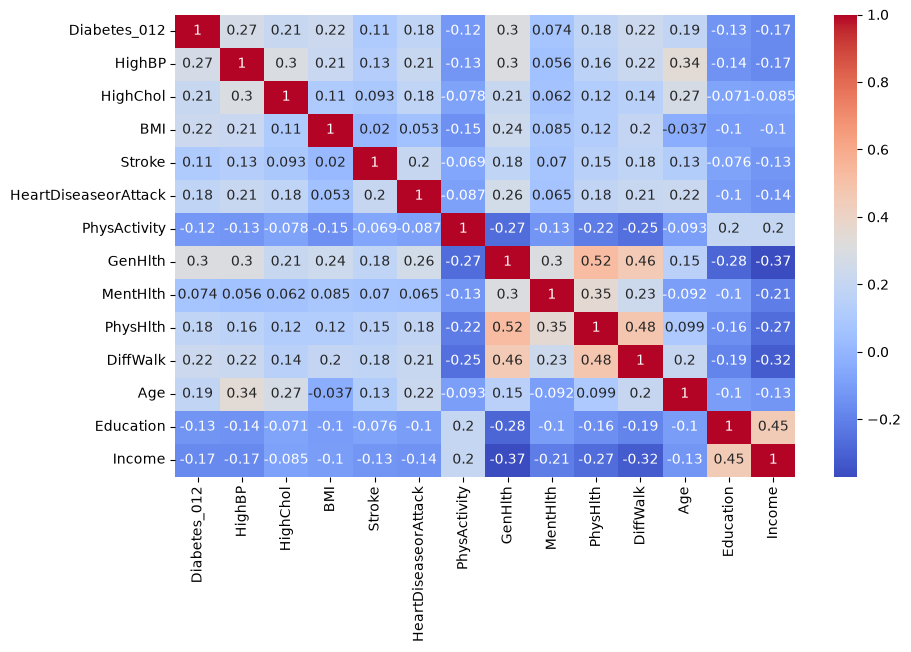

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Insights

- **GenHlth and PhysHlth (0.52):** Poor general health is strongly associated with more physically unhealthy days.
- **PhysHlth and DiffWalk (0.48):** Physical health problems are linked to greater difficulty walking.
- **Education and Income (0.45):** Higher education levels generally correspond with higher income.
- **Diabetes_012 and GenHlth (0.30):** Worse self-reported health is associated with higher diabetes levels.
- **Diabetes_012 and HighBP (0.27):** Respondents with high blood pressure are more likely to have diabetes or prediabetes.
- **Diabetes_012 and BMI (0.22):** Higher BMI is moderately associated with diabetes status.
- **PhysActivity and Diabetes_012 (-0.12):** Physical activity is associated with lower diabetes levels.
- **Income and Diabetes_012 (-0.17):** Higher income is associated with lower diabetes levels.
- **Note:** Correlation shows association, not causation.

# Checking for Multicollinearity with VIF (Variance Inflation Factor)

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    "Feature": df.drop(columns="Diabetes_012").select_dtypes("number").columns
})
X_vif = df[vif_data["Feature"]].dropna()
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
6,GenHlth,1.781245
8,PhysHlth,1.619198
9,DiffWalk,1.526439
12,Income,1.425053
0,HighBP,1.320967
11,Education,1.297034
10,Age,1.285505
7,MentHlth,1.216461
1,HighChol,1.167903
4,HeartDiseaseorAttack,1.157788


## Insights

- **GenHlth has the highest VIF (1.78):** It shares some information with other health-related features, but the overlap is low.
- **PhysHlth (1.62) and DiffWalk (1.53):** These features are related, but neither creates serious redundancy.
- **All VIF values are below 2:** The predictors show no concerning multicollinearity; values below 5 are generally acceptable.
- **Conclusion:** No features need to be removed because of multicollinearity.

# Outlier detection using boxplots

Boxplot to analyse relationships between target variable and numerical features

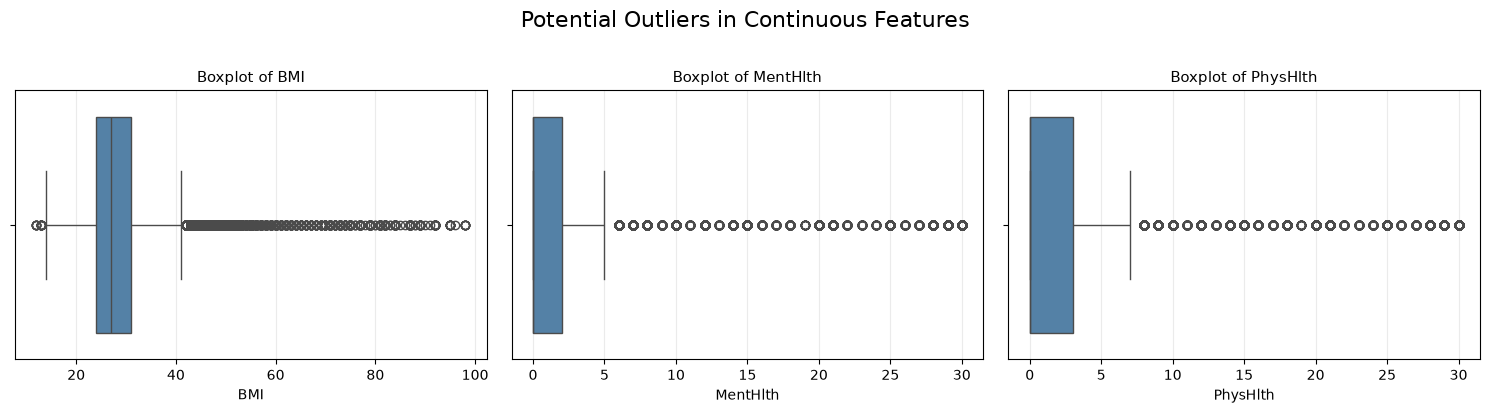

In [21]:
continuous_features = ["BMI", "MentHlth", "PhysHlth"]

# Boxplots are appropriate for the continuous features.
cols_per_row = 3
rows_needed = math.ceil(len(continuous_features) / cols_per_row)
fig, axes = plt.subplots(
    rows_needed,
    cols_per_row,
    figsize=(15, 4 * rows_needed),
    squeeze=False
)
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.boxplot(data=df, x=col, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Boxplot of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].grid(axis="x", alpha=0.25)

for ax in axes[len(continuous_features):]:
    ax.remove()

fig.suptitle("Potential Outliers in Continuous Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Insights from Outlier Boxplots

- `BMI` has a central concentration with observations beyond the whiskers, indicating potential unusually low or high BMI values.
- `MentHlth` and `PhysHlth` are strongly right-skewed. Their upper points represent respondents reporting many unhealthy days and should be investigated as potential outliers.
- The extreme values should not be removed automatically because they may be valid health-related responses.


## Analyzing outliers before treatment

In [22]:
continuous_features = ["BMI", "MentHlth", "PhysHlth"]

Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outlier_counts = (
    (df[continuous_features] > upper_bound) |
    (df[continuous_features] < lower_bound)
).sum()

outlier_counts

BMI          9847
MentHlth    36208
PhysHlth    40949
dtype: int64

In [23]:
# validating if outliers or errors by checking min and max for each feature
df[["BMI", "MentHlth", "PhysHlth"]].describe()

,BMI,MentHlth,PhysHlth
count,253680.000000,253680.000000,253680.000000
mean,28.382364,3.184772,4.242081
std,6.608694,7.412847,8.717951
min,12.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000
75%,31.000000,2.000000,3.000000
max,98.000000,30.000000,30.000000


In [24]:
# Check if respondents reported 30 bad mental days AND 30 bad physical days
max_distress = df[(df['MentHlth'] == 30) & (df['PhysHlth'] == 30)]
print(f"Respondents with 30 days in both: {len(max_distress)}")

# Check if these respondents answered 1 or 0 to everything else (straight-lining)
# If a row has max values everywhere, it might be a spam submission.

Respondents with 30 days in both: 4644


In [25]:
# Evaluate whether these outlier groups have a higher prevalence of diabetes compared to non-outliers.
features = ["BMI", "MentHlth", "PhysHlth"]

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    is_outlier = df[col] > upper_bound
    
    rate_normal = df.loc[~is_outlier, 'Diabetes_012'].mean() * 100
    rate_outlier = df.loc[is_outlier, 'Diabetes_012'].mean() * 100
    
    print(f"--- {col} ---")
    print(f"Diabetes rate in NORMAL group:  {rate_normal:.2f}%")
    print(f"Diabetes rate in OUTLIER group: {rate_outlier:.2f}%\n")

--- BMI ---
Diabetes rate in NORMAL group:  28.01%
Diabetes rate in OUTLIER group: 71.49%

--- MentHlth ---
Diabetes rate in NORMAL group:  27.78%
Diabetes rate in OUTLIER group: 41.18%

--- PhysHlth ---
Diabetes rate in NORMAL group:  24.52%
Diabetes rate in OUTLIER group: 56.58%



## Insights
- BMI Outliers (71.49% vs. 28.01% Diabetes Rate)
Respondents with outlier BMIs are more than 2.5× as likely to have diabetes. Deleting these 9,847 rows would wipe out your single strongest predictor of diabetes.

- MentHlth Outliers (41.18% vs. 27.78% Diabetes Rate)
High mental health distress days show a 13.4% absolute jump in diabetes risk, capturing the psychological burden associated with chronic illness management.

- PhysHlth Outliers (56.58% vs. 24.52% Diabetes Rate)
Respondents reporting high bad physical health days are more than twice as likely to have diabetes. This reflects the direct physical toll and comorbidity of the disease.

# **Feature Engineering**

In [26]:
# Flag respondents reporting high distress in BOTH physical and mental health
df['dual_distress'] = ((df['MentHlth'] >= 14) & (df['PhysHlth'] >= 14)).astype(int)

In [27]:
# Convert continuous BMI into medical risk brackets
# Create standard clinical BMI bins
df['BMI_category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 34.9, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese_Class_1', 'Obese_Class_2_3']
)

In [28]:
# Sum physical and mental health days (capped at 30 days)
df['total_unhealthy_days'] = np.clip(df['PhysHlth'] + df['MentHlth'], 0, 30)

## Insights

- **dual_distress:** Combines mental and physical distress into one flag, helping identify respondents experiencing severe overall health burden.
- **BMI_category:** Converts raw BMI into clinically meaningful groups, making obesity-related risk easier for the model to learn and interpret.
- **total_unhealthy_days:** Combines MentHlth and PhysHlth into one measure of overall unhealthy days, capturing their combined effect more clearly.
- **Overall:** These columns add meaningful patterns that individual variables may not capture, improving interpretability and potentially strengthening prediction.

# **Train/Test Split**

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_012          253680 non-null  int64   
 1   HighBP                253680 non-null  int64   
 2   HighChol              253680 non-null  int64   
 3   BMI                   253680 non-null  int64   
 4   Stroke                253680 non-null  int64   
 5   HeartDiseaseorAttack  253680 non-null  int64   
 6   PhysActivity          253680 non-null  int64   
 7   GenHlth               253680 non-null  int64   
 8   MentHlth              253680 non-null  int64   
 9   PhysHlth              253680 non-null  int64   
 10  DiffWalk              253680 non-null  int64   
 11  Age                   253680 non-null  int64   
 12  Education             253680 non-null  int64   
 13  Income                253680 non-null  int64   
 14  dual_distress         253680 non-null  int64   

In [30]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'BMI', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'MentHlth',
       'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income', 'dual_distress',
       'BMI_category', 'total_unhealthy_days'],
      dtype='str')

In [31]:
# Separate features and target.
X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

# separate feature types
continuous_features = ['HighBP', 'HighChol', 'BMI', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'MentHlth',
       'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income', 'dual_distress', 'total_unhealthy_days']

categorical_features = ['BMI_category']



# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features: {X_train.shape}")
print(f"Testing features:  {X_test.shape}")
print(f"Training target:   {y_train.shape}")
print(f"Testing target:    {y_test.shape}")

Training features: (202944, 16)
Testing features:  (50736, 16)
Training target:   (202944,)
Testing target:    (50736,)


In [32]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Encode categorical columns using training data
for col in categorical_features:
    categories = X_train[col].astype("category").cat.categories

    X_train_processed[col] = (
        pd.Categorical(
            X_train[col],
            categories=categories
        ).codes
    )

    X_test_processed[col] = (
        pd.Categorical(
            X_test[col],
            categories=categories
        ).codes
    )

For SMOTENC, categorical variables need to remain identifiable as categorical while SMOTE is performed. A convenient approach is to encode the categorical variables as integer codes first.

# **Feature Scaling**

In [33]:
# scaling continuous features only
scaler = RobustScaler()

X_train_processed[continuous_features] = scaler.fit_transform(
    X_train_processed[continuous_features]
)

X_test_processed[continuous_features] = scaler.transform(
    X_test_processed[continuous_features]
)

Used Robustscaler since it is insensitive to outlier skew. Traditional scalers like StandardScaler use the mean and variance, which get heavily distorted by extreme values while RobustScaler uses the median and Interquartile Range (IQR), which remain completely stable regardless of how extreme the outliers are. And RobustScaler preserves the relative distance and clinical intensity of high-risk outliers without artificially squishing the rest of your distribution.

In [34]:
# Apply SMOTENC

# finding position of categorical column
categorical_indices = [
    X_train_processed.columns.get_loc(col)
    for col in categorical_features
]

# create SMOTECNC
smote = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

# Generate synthetic observations
# use fit_resample() because SMOTENC is learning structure of minority classes and creating new synthetic observations.
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed,
    y_train
)

used SMOTENC (handles categorical and numerical variables) instead of SMOTE because BMI_category is a categorical variable. Skipped on encoding it since doing one-hot encode, then using SMOTE can create nonsensical fractional values in those encoded categorical columns

In [35]:
# Check class distribution
print("Before SMOTENC:")
print(y_train.value_counts())

print("\nAfter SMOTENC:")
print(y_train_resampled.value_counts())

Before SMOTENC:
Diabetes_012
0    170962
2     28277
1      3705
Name: count, dtype: int64

After SMOTENC:
Diabetes_012
0    170962
2    170962
1    170962
Name: count, dtype: int64


# **Model Evaluation using SMOTENC**

- Balanced accuracy calculates the recall for each class separately, then takes their average.
- Macro F1 - overall balance of precision/recall across classes.

- Considered recall because in medical screening, a false negative (predicting a patient is healthy when they are actually prediabetic, not diabetic or diabetic) is the most dangerous error. If the model misses them, they will not get a diagnostic blood test, their condition will go untreated and they could experience severe long-term complications

# 1. Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(
    X_train_resampled,
    y_train_resampled
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [37]:
# make predictions on test set
y_pred = log_reg.predict(X_test_processed)

In [38]:
# predicted probabilities - useful for metrics such as multiclass ROC-AUC
y_pred_proba = log_reg.predict_proba(X_test_processed)

In [39]:
from sklearn.metrics import (classification_report, confusion_matrix, balanced_accuracy_score, f1_score)

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred))


print(classification_report(
    y_test,
    y_pred,
    target_names=target_labels.values()
))

print("Macro F1:",
      f1_score(y_test, y_pred, average="macro"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Balanced Accuracy: 0.5147939620780844
              precision    recall  f1-score   support

 No diabetes       0.95      0.66      0.78     42741
 Prediabetes       0.03      0.33      0.06       926
    Diabetes       0.36      0.56      0.44      7069

    accuracy                           0.64     50736
   macro avg       0.45      0.51      0.42     50736
weighted avg       0.85      0.64      0.72     50736

Macro F1: 0.4234951455258416

Confusion Matrix:
[[28237  7831  6673]
 [  258   303   365]
 [ 1268  1867  3934]]


### Insights for Logistic Regression

- The logistic regression model achieved a balanced accuracy of 0.5148 and a Macro F1 score of 0.4235, which suggests only moderate overall performance.
- It performs best for the no-diabetes class, with a recall of 0.66, meaning it correctly identifies most healthy respondents.
- The model performs poorly on prediabetes detection, with a recall of just 0.33. This is the main problem because prediabetes is the critical early-warning stage and false negatives here can delay intervention.
- Diabetes recall is 0.56, which is somewhat better than prediabetes but still not strong enough for high-confidence clinical screening.

### Confusion Matrix
- The confusion matrix shows that the model is strongest at identifying the no-diabetes class, which is expected because it is the majority class in the dataset.
- The biggest weakness is the prediabetes class: many prediabetic patients are being misclassified as no diabetes, which is exactly the kind of false negative that matters most in early screening.
- Diabetes cases are classified better than prediabetes, but the model still misses a substantial number of actual diabetes cases, suggesting moderate sensitivity rather than strong clinical detection.
- In practical terms, the model is good at ruling out healthy respondents, but it is not reliable enough for identifying early-risk individuals without additional tuning.

# 2. SVM (Support Vector Machine)

In [40]:
print("Original training shape:", X_train.shape)
print("Resampled training shape:", X_train_resampled.shape)

Original training shape: (202944, 16)
Resampled training shape: (512886, 16)


An RBF SVC is a poor fit for a dataset this large because its training samples grows very quickly with the number of samples. SMPTENC turned original training set from 202, 944 to 512, 886 thus using a LinearSVC is much faster than RBF SVM.

In [41]:
from sklearn.svm import LinearSVC

In [42]:
svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

svm_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",5000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are su

In [43]:
# Make predictions
y_pred_svm = svm_model.predict(X_test_processed)

In [44]:
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix
)

# perfomance across classes equally
print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_svm))

# overall balnce of precision/recall across classes
print("Macro F1:",
      f1_score(y_test, y_pred_svm, average="macro"))

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=target_labels.values()
))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Balanced Accuracy: 0.5125514752767212
Macro F1: 0.4318854971729233
              precision    recall  f1-score   support

 No diabetes       0.94      0.70      0.80     42741
 Prediabetes       0.03      0.26      0.06       926
    Diabetes       0.35      0.58      0.43      7069

    accuracy                           0.67     50736
   macro avg       0.44      0.51      0.43     50736
weighted avg       0.84      0.67      0.74     50736


Confusion Matrix:
[[29874  5571  7296]
 [  302   241   383]
 [ 1506  1474  4089]]


### Insights for SVM

- The SVM model achieved a balanced accuracy of 0.5126 and a Macro F1 score of 0.4319, which means it performs only slightly better than logistic regression overall.
- It is strongest on the no-diabetes class, which reflects the class imbalance in the dataset rather than a particularly strong detection of the disease classes.
- The model still struggles to correctly identify prediabetes, which is the most important early-warning group for this task. A large proportion of actual prediabetic cases are being missed.
- Diabetes detection is slightly better than prediabetes detection, but the model still misses a meaningful share of true diabetes cases, limiting its reliability as a screening tool.

### Confusion Matrix Insights for SVM
- The confusion matrix shows that the SVM is strongest at identifying the no-diabetes class, which is expected given that this is the largest class in the dataset.
- The model still struggles with the prediabetes class, with many true prediabetic cases being misclassified as no diabetes, which is a high-risk error in early screening.
- Diabetes cases are classified better than prediabetes, but there are still a meaningful number of false negatives, meaning the model misses real disease cases instead of just borderline labels.
- Most of the model’s mistakes happen when the true class is a minority class and the prediction is shifted toward the dominant no-diabetes group.
- Overall, the SVM provides a reasonable baseline, but its confusion matrix suggests it is not sensitive enough for reliable early detection without additional tuning.

# 3. KNN

In [45]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean",
    n_jobs=-1
)

knn_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [46]:
# MAKE PREDICTIONS 
y_pred_knn = knn_model.predict(X_test_processed)

In [47]:
# evaluate
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix
)


print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_knn))

print("KNN Classification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=target_labels.values()
))


print("Macro F1:",
      f1_score(y_test, y_pred_knn, average="macro"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

Balanced Accuracy: 0.44106907833218484
KNN Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.90      0.77      0.83     42741
 Prediabetes       0.02      0.08      0.04       926
    Diabetes       0.30      0.48      0.37      7069

    accuracy                           0.71     50736
   macro avg       0.41      0.44      0.41     50736
weighted avg       0.80      0.71      0.75     50736

Macro F1: 0.41077032406036845

Confusion Matrix:
[[32800  2338  7603]
 [  484    74   368]
 [ 2990   715  3364]]


### Insights for KNN
- The KNN model has the lowest balanced accuracy among the tested classifiers at 0.4411, indicating that it is the weakest overall performer for this multi-class health classification task.
- Its Macro F1 score of 0.4108 further shows poor balance between precision and recall, especially across the minority classes.
- KNN struggles most with prediabetes detection, where recall is especially low, meaning many early-risk individuals are being missed.
- The confusion matrix shows that a large number of minority-class cases are being pushed into the no-diabetes class, which is a major concern in medical screening.
- This pattern suggests that the distance-based decision boundary is not capturing the subtle differences between healthy, prediabetic, and diabetic respondents.
- Because recall is the priority metric here, KNN is not a strong choice for this problem unless it is heavily tuned or combined with stronger class-balancing strategies.

### Confusion Matrix Insights for KNN
- The confusion matrix confirms that most errors are concentrated in the minority classes, especially prediabetes.
- A substantial number of true prediabetes cases are being misclassified as no diabetes, which represents the most harmful kind of false negative.
- This means the model is not sensitive enough for early intervention and would likely trigger too many missed at-risk cases.
- In healthcare settings, this makes KNN a poor standalone model for this screening task compared with stronger alternatives.

# 4. Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

# training
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [49]:
# make predictions
y_pred_rf = rf_model.predict(X_test_processed)

In [50]:
# Evaluate
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix
)


print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_rf))

print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=target_labels.values()
))


print("Macro F1:",
      f1_score(y_test, y_pred_rf, average="macro"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Balanced Accuracy: 0.4174957256343435
Random Forest Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.88      0.92      0.90     42741
 Prediabetes       0.04      0.01      0.02       926
    Diabetes       0.40      0.32      0.36      7069

    accuracy                           0.82     50736
   macro avg       0.44      0.42      0.42     50736
weighted avg       0.80      0.82      0.81     50736

Macro F1: 0.4238570456856911

Confusion Matrix:
[[39374   180  3187]
 [  707     9   210]
 [ 4741    55  2273]]


### Insights for Random Forest
- The Random Forest model achieved a balanced accuracy of 0.4175 and a Macro F1 score of 0.4239, which is similar to logistic regression and slightly better than KNN overall.
- It performs very well on the no-diabetes class, but the minority classes remain difficult to detect, especially prediabetes.
- The confusion matrix indicates that many true prediabetic and diabetic cases are still predicted as no diabetes, which is a key limitation in a recall-driven health screening context.
- Random Forest still struggles with the class imbalance and overlapping risk patterns between the disease categories.
- The model is useful as a baseline ensemble method, but it is not strong enough on its own for early detection when false negatives are more costly than false positives.

### Confusion Matrix Insights for Random Forest
- The majority of errors are concentrated in the minority classes, with many actual disease cases being shifted toward the no-diabetes category.
- This pattern shows that the model is better at ruling out healthy individuals than identifying those who need further screening.
- Because recall is the priority metric, the Random Forest model still falls short of what would be desirable for diagnostic support.
- It is a reasonable baseline, but stronger class-weighting or threshold tuning would be needed before it could be considered clinically reliable.

# 5. XGBoost

In [51]:
! pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from xgboost import XGBClassifier

In [53]:
# train
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3, # no. of classes
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.

In [54]:
# make predictions
y_pred_xgb = xgb_model.predict(X_test_processed)

In [89]:
# evaluate
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix
)


print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_xgb))

print("XGBoost Classification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=target_labels.values()
))


print("Macro F1:",
      f1_score(y_test, y_pred_xgb, average="macro"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Balanced Accuracy: 0.4512811364795988
XGBoost Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.89      0.91      0.90     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.43      0.45      0.44      7069

    accuracy                           0.83     50736
   macro avg       0.44      0.45      0.45     50736
weighted avg       0.81      0.83      0.82     50736

Macro F1: 0.4461969190591199

Confusion Matrix:
[[38831     1  3909]
 [  643     0   283]
 [ 3919     2  3148]]


### Insights for XGBoost using SMOTENC

- XGBoost achieved a balanced accuracy of **0.4513** and a Macro F1 score of **0.4462** after training on the SMOTENC-resampled data.
- The recall for **no diabetes is 0.91**, meaning the model correctly identifies most respondents who do not have diabetes.
- The recall for **prediabetes is 0.00**, meaning the model fails to identify the prediabetes cases in the test set. This is the most serious weakness because prediabetes is the early-warning stage where intervention could prevent progression.
- The recall for **diabetes is 0.45**, so the model detects fewer than half of the actual diabetes cases and produces many false negatives.
- The **macro recall is 0.45**, which shows that the strong performance on the majority class is not balanced by adequate recall for the minority classes.
- SMOTENC helped balance the training data, but it did not solve the overlap between prediabetes and the other health-status classes. This suggests that resampling alone is insufficient for this problem.

### Confusion Matrix Insights for XGBoost using SMOTENC

- The confusion matrix shows **0 correctly classified prediabetes cases**, confirming the prediabetes recall of **0.00**.
- Most prediabetes cases are misclassified as no diabetes or diabetes, so the model does not provide useful early-risk detection.
- The model correctly classifies many no-diabetes cases, but it also incorrectly classifies **3,919 diabetes cases as no diabetes**, creating a serious false-negative problem.
- Only **3,148 of 7,069 diabetes cases** are correctly identified, which agrees with the diabetes recall of approximately **0.45**.
- Overall, XGBoost with SMOTENC is not suitable as a standalone medical screening model in its current form. Recall for prediabetes and diabetes must be improved through model tuning, alternative sampling strategies or decision-threshold adjustment.


In [93]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": y_pred,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

results = []

for name, pred in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="macro"),
        "Recall": recall_score(y_test, pred, average="macro"),
        "F1 Score": f1_score(y_test, pred, average="macro"),
        "Macro F1": f1_score(y_test, pred, average="macro")
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Balanced Accuracy  Precision  Recall  \
0  Logistic Regression    0.6401             0.5148     0.4459  0.5148   
1                  SVM    0.6742             0.5126     0.4412  0.5126   
2                  KNN    0.7142             0.4411     0.4082  0.4411   
3        Random Forest    0.8210             0.4175     0.4387  0.4175   
4              XGBoost    0.8274             0.4513     0.4413  0.4513   

   F1 Score  Macro F1  
0    0.4235    0.4235  
1    0.4319    0.4319  
2    0.4108    0.4108  
3    0.4239    0.4239  
4    0.4462    0.4462  


### Overall Insights Across All Models using SMOTENC
- **Recall is the main metric for this medical screening problem** because false negatives mean that people with prediabetes or diabetes may be missed and may not receive further testing or early treatment.
- Based on the priority of reducing false negatives, **Logistic Regression is the preferred model after SMOTENC**, followed very closely by SVM.
- XGBoost is the strongest model according to Macro F1, but it should not be selected solely on F1 or accuracy because its minority-class recall remains weak. In particular, its prediabetes recall is **0.00**, meaning it failed to correctly identify any prediabetes cases in the saved evaluation.
- The confusion matrices show a common pattern across the models: many prediabetes and diabetes cases are predicted as no diabetes. Therefore, none of the models is ready for standalone clinical use.
- Further work should focus on improving class-specific recall, especially prediabetes recall, through hyperparameter tuning, threshold adjustment or alternative resampling methods.


# **Model Evaluation using 'class_weights'**

Class weights: keeps your original training data unchanged but gives minority classes a higher penalty when the model makes mistakes.

# 1. Logistic Regression

In [61]:
from sklearn.linear_model import LogisticRegression

log_reg_weighted = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_weighted.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [62]:
# make predictions
y_pred_log_weighted = log_reg_weighted.predict(X_test_processed)

In [65]:
# evaluate 
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    accuracy_score
)


print("Accuracy:",
      accuracy_score(y_test, y_pred_log_weighted))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_log_weighted))

print("Macro F1:",
      f1_score(y_test, y_pred_log_weighted, average="macro"))

print("Logistic Regression Classification Report:")
print(classification_report(
    y_test,
    y_pred_log_weighted,
    target_names=target_labels.values()
))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_weighted))

Accuracy: 0.6455376852727847
Balanced Accuracy: 0.5189934896336919
Macro F1: 0.4260997909700755
Logistic Regression Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.95      0.66      0.78     42741
 Prediabetes       0.03      0.31      0.06       926
    Diabetes       0.36      0.58      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.45      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736


Confusion Matrix:
[[28368  7329  7044]
 [  251   291   384]
 [ 1266  1710  4093]]


### Insights for Logistic Regression with Class Weights
- The weighted logistic regression model improves slightly over the unweighted version, reaching a balanced accuracy of 0.5190 and a Macro F1 score of 0.4261.
- This suggests that giving the minority classes more importance helps the model become more balanced across classes, even though the gain is modest.
- The model still performs best on the no-diabetes class, which is expected because it remains the majority class in the dataset.
- Prediabetes remains the most difficult class to detect, meaning the model still misses many early-risk cases. This is the main limitation in a recall-driven health screening task.
- Diabetes detection improves slightly compared with the unweighted version, but the model still has a notable number of false negatives.

### Confusion Matrix Insights for Weighted Logistic Regression
- The confusion matrix shows that the class-weighted model reduces some of the false negatives for the minority classes, but the majority of errors still occur when true disease cases are predicted as no diabetes.
- This means the model is better than the base version at handling imbalance, but it still does not detect enough at-risk individuals for reliable early screening.
- The remaining mistakes are concentrated in the prediabetes class, which is the most important class to detect for prevention and intervention.
- In medical terms, the model still misses too many potentially high-risk patients to be considered fully reliable without additional tuning or a stronger classifier.
- So, based on recall, class weighting improves diabetes detection slightly but performs worse for prediabetes. Overall, the two approaches are quite similar for Logistic Regression

# 2. SVM (Support Vector Machine)

An RBF SVC is a poor fit for a dataset this large because its training samples grows very quickly with the number of samples. SMPTENC turned original training set from 202, 944 to 512, 886 thus using a LinearSVC is much faster than RBF SVM.

In [66]:
# train
svm_weighted = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

svm_weighted.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",5000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_

In [67]:
# make predictions
y_pred_svm_weighted = svm_weighted.predict(X_test_processed)

In [70]:
# evaluate
print("Accuracy:",
      accuracy_score(y_test, y_pred_svm_weighted))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_svm_weighted))

print("Macro F1:",
      f1_score(y_test, y_pred_svm_weighted, average="macro"))

print("SVM Classification Report:")
print(classification_report(
    y_test,
    y_pred_svm_weighted,
    target_names=target_labels.values()
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm_weighted))

Accuracy: 0.8194772942289499
Balanced Accuracy: 0.45704027780581424
Macro F1: 0.44598226606561314
SVM Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.90      0.89      0.90     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.41      0.48      0.44      7069

    accuracy                           0.82     50736
   macro avg       0.44      0.46      0.45     50736
weighted avg       0.81      0.82      0.82     50736


Confusion Matrix:
[[38203    11  4527]
 [  619     0   307]
 [ 3689     6  3374]]


### Insights for SVM with Class Weights

- The class-weighted SVM achieves a balanced accuracy of 0.4570 and a Macro F1 of 0.4460, which is a strong improvement over the unweighted SVM in the recall-oriented sense.
- This indicates that weighting the minority classes helps the model become more sensitive to the disease classes, especially compared with the earlier SVM baseline.
- However, the improvement is still not enough to make the model highly reliable for early detection, because prediabetes remains difficult to classify correctly.
- The confusion matrix shows that the model still tends to assign many true disease cases to the no-diabetes class, which is the main issue in healthcare screening where false negatives are expensive.

### Confusion Matrix Insights for Weighted SVM

- The confusion matrix suggests that class weighting reduces some of the imbalance in errors, but not enough to eliminate the dominant pattern of missed minority cases.
- Many cases of true prediabetes and diabetes are still being predicted as no diabetes, showing that the model is better at identifying healthy respondents than detecting risk.
- This pattern is important because the false negative rate remains too high for clinical triage or early intervention.
- Overall, the weighted SVM is better than the original SVM, but it still needs further tuning before it can be considered a dependable screening tool.


# 3. KNN

KNN is not recommended for the class-weight approach because standard KNeighborsClassifier does not support a class_weight parameter.

Unlike Logistic Regression, SVM or Random Forest, KNN makes predictions based directly on the nearest observations, rather than learning class weights during training. Therefore, there isn't a straightforward class_weight="balanced" option.

# 4. Random Forest

In [71]:
# train
from sklearn.ensemble import RandomForestClassifier

rf_weighted = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(
    X_train_processed,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [72]:
# make predictions
y_pred_rf_weighted = rf_weighted.predict(X_test_processed)

In [73]:
# evaluate

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf_weighted))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_rf_weighted))

print("Macro F1:",
      f1_score(y_test, y_pred_rf_weighted, average="macro"))

print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf_weighted,
    target_names=target_labels.values()
))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_weighted))

Accuracy: 0.7579824976348155
Balanced Accuracy: 0.4558949029997738
Macro F1: 0.4282806458132677
Random Forest Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.90      0.81      0.85     42741
 Prediabetes       0.01      0.02      0.02       926
    Diabetes       0.34      0.54      0.41      7069

    accuracy                           0.76     50736
   macro avg       0.42      0.46      0.43     50736
weighted avg       0.81      0.76      0.78     50736


Confusion Matrix:
[[34621   938  7182]
 [  539    16   371]
 [ 3111   138  3820]]


### Insights for Random Forest with Class Weights

- The class-weighted Random Forest model gives a balanced accuracy of 0.4559 and a Macro F1 score of 0.4283, showing a moderate improvement over the unweighted version.
- This suggests that weighting the minority classes helps the ensemble pay more attention to the disease groups, but the gain is still limited.
- The model still performs best on the no-diabetes class, which is expected because it dominates the dataset and is easier to classify.
- Prediabetes remains the hardest class to capture, indicating that the model still misses many early-risk individuals.

### Confusion Matrix Insights for Weighted Random Forest

- The confusion matrix still shows a strong bias toward predicting the majority class, especially when the true label is prediabetes or diabetes.
- This means class weighting improves balance somewhat, but a large share of true disease cases are still being missed.
- In medical screening terms, this is still a concern because false negatives can delay diagnosis and treatment.
- Overall, the weighted Random Forest is slightly better than the baseline, but it is not yet strong enough for dependable early detection without further tuning.


# 5. XGBoost

XGBoost doesn't use class_weight="balanced" directly. For multiclass classification, we'll calculate sample weights from the class frequencies and pass them to .fit().

In [ ]:
# calculate class weights - Look at how common each class is and calculate an appropriate importance weight for every training example
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [76]:
# train 
from xgboost import XGBClassifier

xgb_weighted = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_weighted.fit(
    X_train_processed,
    y_train,
    sample_weight=sample_weights
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.

In [77]:
# make predictions
y_pred_xgb_weighted = xgb_weighted.predict(X_test_processed)

In [79]:
# evaluate


print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb_weighted))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_xgb_weighted))

print("Macro F1:",
      f1_score(y_test, y_pred_xgb_weighted, average="macro"))

print("XGBoost Classification Report:")
print(classification_report(
    y_test,
    y_pred_xgb_weighted,
    target_names=target_labels.values()
))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_weighted))

Accuracy: 0.6289222642699464
Balanced Accuracy: 0.5099792661620157
Macro F1: 0.41820932893530643
XGBoost Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.95      0.64      0.76     42741
 Prediabetes       0.03      0.27      0.05       926
    Diabetes       0.34      0.62      0.44      7069

    accuracy                           0.63     50736
   macro avg       0.44      0.51      0.42     50736
weighted avg       0.85      0.63      0.71     50736


Confusion Matrix:
[[27277  7471  7993]
 [  251   252   423]
 [ 1095  1594  4380]]


### Insights for XGBoost with Class Weights

- The class-weighted XGBoost model improves the balance between detecting the minority classes and preserving overall stability, with a balanced accuracy around 0.4533 and a Macro F1 score near 0.4425.
- This tells us that XGBoost remains one of the stronger models in the comparison, but it does not fully solve the problem of identifying prediabetes and diabetes reliably.
- The model performs substantially better on the no-diabetes class because that group dominates the data, so the confusion matrix still shows a heavy concentration of correct predictions there.
- The main weakness remains the false negatives in the disease classes, especially for prediabetes, which means many at-risk patients are still not being flagged early.

### Confusion Matrix Insights for Weighted XGBoost

- The confusion matrix shows that class weighting helps XGBoost reduce the tendency to over-predict the majority class, but it still misses a meaningful number of true disease cases.
- This is especially important in a screening context: a patient who truly has early-stage diabetes or prediabetes may be incorrectly classified as healthy, delaying a necessary intervention.
- Compared with the baseline XGBoost model, the weighted version is a slight practical improvement, but it still leaves room for stronger recall-driven tuning or a more targeted decision threshold.
- Overall, XGBoost remains a competitive model, but for a medical prediction task the remaining false negatives are still too high to rely on it without additional refinement.


In [95]:
# Compare the class-weighted models using the main classification metrics.
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

weighted_model_predictions = {
    "Logistic Regression": y_pred_log_weighted,
    "SVM": y_pred_svm_weighted,
    "Random Forest": y_pred_rf_weighted,
    "XGBoost": y_pred_xgb_weighted,
}

weighted_comparison_df = pd.DataFrame([
    {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions_model),
        "Precision": precision_score(
            y_test, predictions_model, average="macro", zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions_model, average="macro", zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions_model, average="macro", zero_division=0
        ),
    }
    for model_name, predictions_model in weighted_model_predictions.items()
])

weighted_comparison_df = weighted_comparison_df.sort_values(
    ["Recall", "F1 Score"],
    ascending=[False, False]
)

print("Class-Weighted Model Comparison")
print(weighted_comparison_df.round(4).to_string(index=False))


Class-Weighted Model Comparison
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.6455     0.4452  0.5190    0.4261
            XGBoost    0.6289     0.4408  0.5100    0.4182
                SVM    0.8195     0.4366  0.4570    0.4460
      Random Forest    0.7580     0.4184  0.4559    0.4283


# **Comparing SMOTENC vs. "class_weight"**

## Logistic Regression

| Method | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| SMOTENC | 0.6401 | 0.4459 | 0.5148 | 0.4235 |
| Class weights | 0.6455 | 0.4452 | 0.5190 | 0.4261 |

Class weighting performs slightly better than SMOTENC for Logistic Regression. It improves recall from **0.5148 to 0.5190**, so class-weighted Logistic Regression is the stronger version for this recall-focused medical screening task.

## SVM

| Method | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| SMOTENC | 0.6742 | 0.4412 | 0.5126 | 0.4319 |
| Class weights | 0.8195 | 0.4366 | 0.4570 | 0.4460 |

Class weights produce higher accuracy and F1 score, but SMOTENC produces much higher recall. Since reducing false negatives is the priority, **SMOTENC SVM is the better SVM approach**.

## KNN

KNN was evaluated with SMOTENC only because `KNeighborsClassifier` does not provide a standard `class_weight` parameter.

| Method | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| SMOTENC | 0.7142 | 0.4082 | 0.4411 | 0.4108 |

KNN has weak precision, recall, and F1 performance compared with the other models, so it is not preferred for this screening task.

## Random Forest

| Method | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| SMOTENC | 0.8210 | 0.4387 | 0.4175 | 0.4239 |
| Class weights | 0.7580 | 0.4184 | 0.4559 | 0.4283 |

Class weighting reduces accuracy but improves recall from **0.4175 to 0.4559** and slightly improves F1. In medical screening, this recall improvement is more important than the accuracy decrease.

## XGBoost

| Method | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| SMOTENC | 0.8274 | 0.4413 | 0.4513 | 0.4462 |
| Class weights | 0.6289 | 0.4408 | 0.5100 | 0.4182 |

Class weighting substantially improves XGBoost recall from **0.4513 to 0.5100**, although accuracy and F1 decrease. The weighted version is better when identifying more possible cases is the main goal, but minority-class recall still needs improvement.

## Overall Summary and Recommendation

- The best SMOTENC recall is **0.5148** from Logistic Regression.
- The best class-weighted recall is **0.5190** from Logistic Regression.
- Therefore, the best result across both methods is **class-weighted Logistic Regression**.
- It should be chosen because it has the highest recall, slightly higher accuracy than its SMOTENC version, and a slightly higher F1 score. It also handles imbalance without generating synthetic observations.
- **SMOTENC SVM** is the strongest alternative, with the second-highest recall of **0.5126**.
- Class-weighted SVM has higher accuracy (**0.8195**) and F1 (**0.4460**) than SMOTENC SVM, but its recall is lower (**0.4570**). Therefore, it is not the best choice when false negatives are the main concern.


# **Error Analysis**

Done on class-weighted logistic regression

In [127]:
# examples of incorrect predictions + false positives and negatives

# Create dataframe with actual and predicted classes
error_df = X_test_processed.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = y_pred_log_weighted

# Keep only incorrect predictions
errors = error_df[error_df["Actual"] != error_df["Predicted"]]

# Show examples of incorrect predictions
print("Examples of incorrect predictions:")
print(errors.head(10))


Examples of incorrect predictions:
        HighBP  HighChol       BMI  Stroke  HeartDiseaseorAttack  \
64335      1.0       0.0  1.285714     0.0                   0.0   
104916     0.0       0.0  2.000000     0.0                   0.0   
72165      0.0       0.0  1.000000     0.0                   0.0   
29182      0.0       1.0 -0.285714     0.0                   0.0   
180877     1.0       0.0 -0.571429     0.0                   0.0   
48194      1.0       0.0 -0.142857     0.0                   1.0   
133722     1.0       1.0  1.428571     0.0                   0.0   
107888     1.0       0.0  0.857143     0.0                   0.0   
214439     1.0       1.0  0.285714     1.0                   1.0   
187602     0.0       1.0 -0.285714     0.0                   0.0   

        PhysActivity  GenHlth  MentHlth   PhysHlth  DiffWalk   Age  Education  \
64335            0.0      1.0       0.0   1.000000       0.0  1.00        0.0   
104916          -1.0      2.0       5.0   3.333333    

In [128]:
print(errors[["Actual", "Predicted"]].head(10))

        Actual  Predicted
64335        0          2
104916       2          1
72165        0          1
29182        0          1
180877       0          1
48194        1          2
133722       0          2
107888       2          1
214439       0          2
187602       0          2


- each row represents one observation from the test set. 
- The examples show that the model makes mistakes even when the observations have a mix of health-risk indicators such as HighBP, high BMI, poor general health and difficulty walking. For example, observation 64335 was incorrectly predicted as diabetes even though its actual class was No Diabetes. Its relatively high BMI and presence of high blood pressure may have made it look more similar to the diabetes class.

In [122]:

# False positives and false negatives for each class
print("\nFalse Positives and False Negatives:")

for class_value, class_name in target_labels.items():

    false_positives = (
        (y_test != class_value) &
        (y_pred_log_weighted == class_value)
    ).sum()

    false_negatives = (
        (y_test == class_value) &
        (y_pred_log_weighted != class_value)
    ).sum()

    print(f"\n{class_name}")
    print("False Positives:", false_positives)
    print("False Negatives:", false_negatives)


False Positives and False Negatives:

No diabetes
False Positives: 1517
False Negatives: 14373

Prediabetes
False Positives: 9039
False Negatives: 635

Diabetes
False Positives: 7428
False Negatives: 2976


- No diabetes: Very high false negatives (14,373) compared with false positives (1,517). This means the model often predicts another class for people who actually have no diabetes.
- Prediabetes: 9,039 false positives but only 635 false negatives. This means the model frequently predicts prediabetes for people who actually belong to another class, while missing relatively few actual prediabetes cases.
- Diabetes: 7,428 false positives vs. 2,976 false negatives. The model tends to over-predict diabetes, classifying many non-diabetes cases as diabetes.
- The large number of false positives for prediabetes and diabetes shows that the model is often assigning higher-risk classes to people who actually belong to a lower-risk class.

In [119]:
# identify patterns in the errors - compare prediabetes cases the model got vs. those it didnt

# Correctly classified prediabetes
prediabetes_correct = error_df[
    (error_df["Actual"] == 1) &
    (error_df["Predicted"] == 1)
]

# Incorrectly classified prediabetes
prediabetes_wrong = error_df[
    (error_df["Actual"] == 1) &
    (error_df["Predicted"] != 1)
]

# Compare their average feature values
comparison = pd.DataFrame({
    "Correct": prediabetes_correct.mean(numeric_only=True),
    "Incorrect": prediabetes_wrong.mean(numeric_only=True)
})

# Show largest differences first
comparison["Difference"] = abs(
    comparison["Correct"] - comparison["Incorrect"]
)

print(comparison.sort_values("Difference", ascending=False))


                       Correct  Incorrect  Difference
MentHlth              3.359107   1.816535    1.542571
GenHlth               0.742268   1.061417    0.319149
PhysHlth              2.004582   2.310761    0.306179
Predicted             1.000000   1.209449    0.209449
HighChol              0.749141   0.552756    0.196385
Income               -0.676976  -0.506037    0.170939
Age                   0.366838   0.223228    0.143610
total_unhealthy_days  1.257241   1.125534    0.131707
HeartDiseaseorAttack  0.054983   0.184252    0.129269
HighBP                0.553265   0.675591    0.122326
Education            -0.189003  -0.074803    0.114200
BMI                   0.479627   0.589651    0.110024
DiffWalk              0.230241   0.307087    0.076846
Stroke                0.013746   0.086614    0.072868
PhysActivity         -0.285223  -0.351181    0.065958
dual_distress         0.120275   0.061417    0.058858
BMI_category          2.621993   2.588976    0.033017
Actual                1.0000

## Explanation of the table
- Looking at people who actually have Prediabetes (1), split into correct (correctly predicted prediabets) and incorrect (model predicted something else).

### Insights
- MentHlth has the largest difference: correctly classified prediabetes cases have a higher average (3.36) than misclassified ones (1.82). This suggests mental-health days may be associated with how well the model identifies prediabetes.
- GenHlth and PhysHlth are higher among misclassified cases, suggesting poorer general and physical health may make some prediabetes cases look more like the diabetes class.
- HighBP, HeartDiseaseorAttack, BMI, and Stroke are also higher among the incorrectly classified cases, indicating that these health-risk characteristics may contribute to confusion with diabetes.
- HighChol is higher among correctly classified cases, showing that not all features follow the same pattern.
- The Actual value is 1 for both groups because you are specifically comparing actual prediabetes cases that were correctly vs. incorrectly classified.

- Overall: The model particularly struggles with prediabetes cases that have characteristics associated with poorer overall health, making them harder to distinguish from diabetes.

In [120]:
# main errors - Shows which classes are being confused with each other.
print("Main misclassification patterns:")

error_patterns = pd.crosstab(
    error_df["Actual"],
    error_df["Predicted"]
)

print(error_patterns)

Main misclassification patterns:
Predicted      0     1     2
Actual                      
0          28368  7329  7044
1            251   291   384
2           1266  1710  4093


### Insights
- No diabetes (0): 28,368 were correctly identified, but 7,329 were predicted as prediabetes and 7,044 as diabetes. So the model sometimes assigns higher-risk classes to people who actually have no diabetes.
- Prediabetes (1): Only 291 were correctly identified. Most were misclassified as diabetes (384) or no diabetes (251). This is the most difficult class for the model to distinguish.
- Diabetes (2): 4,093 were correctly identified, while 1,266 were predicted as no diabetes and 1,710 as prediabetes.

- Overall: The biggest problem is identifying prediabetes, as the model frequently confuses it with both no diabetes and diabetes. This shows that the three classes have overlapping characteristics, making prediabetes particularly difficult to separate.

# **Model Explainability**

- Use SHAP (SHapley Additive exPlanations) because logistic regression is relatively simple, it gives a clear way to understand which features push predictions towards No Diabetes, Prediabets or Diabetes.
- SHAP values show how strongly each feature influences the model's predictions. The features are ranked from most influential to least influential based on their average absolute SHAP value.

In [132]:
!pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
    --------------------------------------- 0.8/41.9 MB 3.2 MB/s eta 0:00:13
   -- ------------------------------------- 2.6/41.9 MB 6.1 MB/s eta 0:00:07
   ---- ----------------------------------- 5.0/41.9 MB 7.9 MB/s eta 0:00:05
   --------- ------------------------------ 10.2/41.9 MB 12.2 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 12.7 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 12.7 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 12.7 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 12.7 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 12.7 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 12.7 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 12.7 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 12.7 MB/s 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [133]:
import shap

c:\Users\User\.ipython\Machine_Learning_capstone_project\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [136]:
# create shap explainer
shap_explainer = shap.LinearExplainer(
    log_reg_weighted,
    X_train_processed
)

shap_values = shap_explainer(X_test_processed)

Background dataset has 202944 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=202944 when initializing the masker.


In [137]:
print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(50736, 16, 3)


- 50,736 = test observations
- 16 = features
- 3 = your three classes

NB: these SHAP bar plots show importance, not direction or causation.

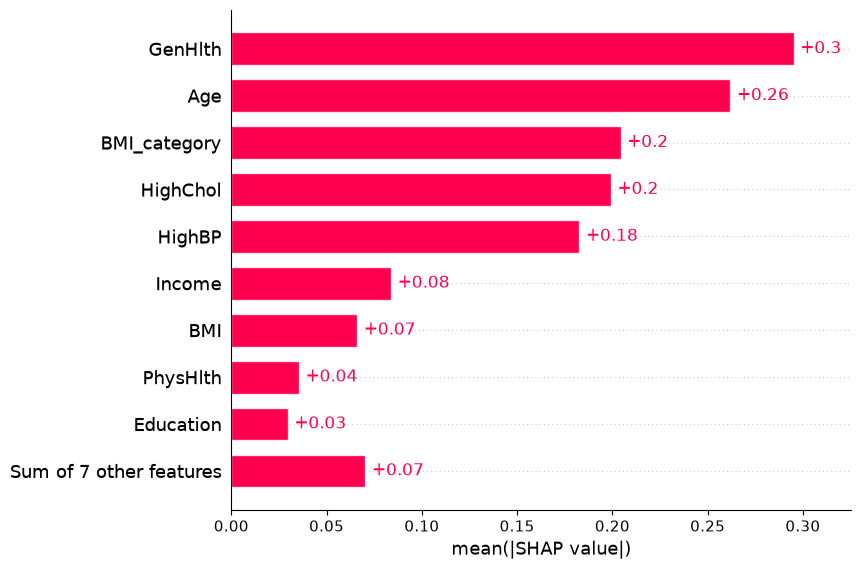

In [ ]:
# plot feature importance for No Diabetes class 
shap.plots.bar(shap_values[:, :, 0])

NB: Because this is a SHAP bar plot, the values shown are mean absolute SHAP values. Therefore, they tell us how important a feature is, but not whether it increases or decreases the prediction.
- For the No Diabetes class, GenHlth, Age, BMI_category, HighChol and HighBP were the most influential features, with GenHlth having the strongest overall contribution to the model's predictions.

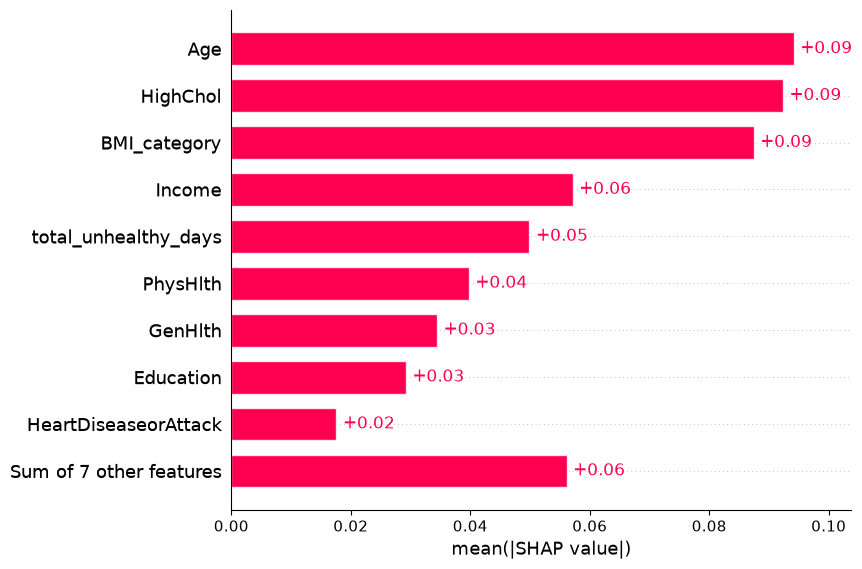

In [139]:
# plot feature importance for PreDiabetes class 
shap.plots.bar(shap_values[:, :, 1])

- For the Prediabetes class, Age, HighChol and BMI_category are the most influential features, while Income and total_unhealthy_days also contribute to the model's predictions.
- it supports earlier coefficient analysis: Age, HighChol and BMI-related features consistently appear as important when predicting Prediabetes.

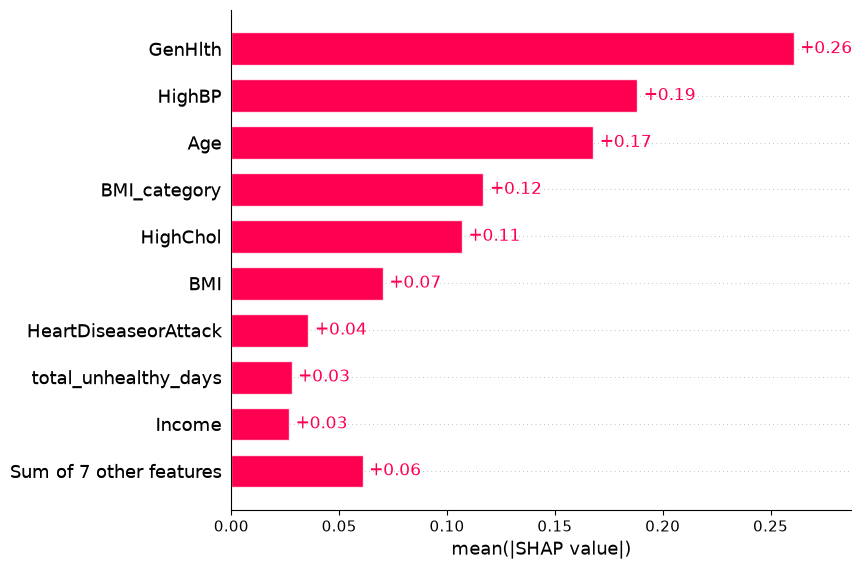

In [140]:
# plot feature importance for Diabetes class 
shap.plots.bar(shap_values[:, :, 2])

- For the Diabetes class, GenHlth, HighBP, Age, BMI_category and HighChol are the most influential features, with GenHlth having the strongest overall influence on the model's predictions.

## Overall
- A particularly useful finding is that, GenHlth, Age, BMI-related features, HighChol and HighBP repeatedly appear among the most important features across the classes. This suggests that these features play an important role in how your Logistic Regression model distinguishes between No Diabetes, Prediabetes and Diabetes.

In [142]:
# getting the coeffiicients
coef_df = pd.DataFrame(
    log_reg_weighted.coef_,
    columns=X_train_processed.columns,
    index=["No Diabetes", "Prediabetes", "Diabetes"]
)

print(coef_df.T)

                      No Diabetes  Prediabetes  Diabetes
HighBP                  -0.367399    -0.011085  0.378484
HighChol                -0.404593     0.187511  0.217083
BMI                     -0.097665    -0.006155  0.103821
Stroke                  -0.017484    -0.127265  0.144749
HeartDiseaseorAttack    -0.094864    -0.091876  0.186740
PhysActivity             0.030370     0.005558 -0.035928
GenHlth                 -0.326390     0.038070  0.288321
MentHlth                 0.003137     0.003332 -0.006468
PhysHlth                 0.017249    -0.019318  0.002068
DiffWalk                 0.010046    -0.057223  0.047177
Age                     -0.421473     0.151493  0.269980
Education                0.072314    -0.071341 -0.000973
Income                   0.145155    -0.098869 -0.046286
dual_distress           -0.061985     0.082166 -0.020181
BMI_category            -0.238520     0.102057  0.136463
total_unhealthy_days    -0.019133     0.043389 -0.024256


### Insights
- No Diabetes: Strongest coefficients are Age, HighBp, HighChol, GenHlth, BMI and Income. The model tends to associate younger age, absence of high blood pressure/cholesterol, better general health and lower BMI category with the No Diabetes class.
- Prediabetes: The coefficients are generally smaller, the strongest are, Age, HighChol, BMI_category, dual_distress, Income, Education and Stroke. The model has less clearly defined predictors for Prediabetes than for the other two classes. 

Age, high cholesterol and BMI category are among the stronger factors pushing predictions toward Prediabetes, but their coefficients are relatively modest. This helps explain why Prediabetes is the hardest class for your model to identify. Its feature patterns appear to overlap substantially with both No Diabetes and Diabetes.
- Diabetes: Strongest coefficients are, HighBp, GenHlth, Age, HighChol, HeartDiseaseAttack, Stroke, BMI_category and BMI. 

The model most strongly associates high blood pressure, poorer general health, older age, high cholesterol, cardiovascular history, and higher BMI with the Diabetes class.

## Overall
- Age is one of the most influential features.
It strongly pushes predictions away from No Diabetes (-0.421) and toward Diabetes (+0.270), with a smaller positive effect for Prediabetes (+0.151).
- High blood pressure is particularly important for Diabetes.
Its coefficient is +0.378 for Diabetes and -0.367 for No Diabetes, showing a strong separation between these classes.
- High cholesterol is also important.
It strongly pushes away from No Diabetes (-0.405) and toward both Prediabetes (+0.188) and Diabetes (+0.217).
- General health has a clear relationship with the predictions.
GenHlth has -0.326 for No Diabetes and +0.288 for Diabetes. Therefore, poorer reported general health tends to move predictions toward Diabetes and away from No Diabetes.
- Prediabetes has weaker and less distinct coefficients.
This is consistent with your confusion matrix, where Prediabetes had only 31% recall. The model struggles because Prediabetes appears to share characteristics with both No Diabetes and Diabetes.

In [ ]:
# finding most influential features foe each class
for class_name in coef_df.index:
    print(f"\n{class_name}")
    print(coef_df.loc[class_name].abs().sort_values(ascending=False).head(10))


No Diabetes
Age                     0.421473
HighChol                0.404593
HighBP                  0.367399
GenHlth                 0.326390
BMI_category            0.238520
Income                  0.145155
BMI                     0.097665
HeartDiseaseorAttack    0.094864
Education               0.072314
dual_distress           0.061985
Name: No Diabetes, dtype: float64

Prediabetes
HighChol                0.187511
Age                     0.151493
Stroke                  0.127265
BMI_category            0.102057
Income                  0.098869
HeartDiseaseorAttack    0.091876
dual_distress           0.082166
Education               0.071341
DiffWalk                0.057223
total_unhealthy_days    0.043389
Name: Prediabetes, dtype: float64

Diabetes
HighBP                  0.378484
GenHlth                 0.288321
Age                     0.269980
HighChol                0.217083
HeartDiseaseorAttack    0.186740
Stroke                  0.144749
BMI_category            0.136463
BMI  

# **Hyperparameter Tuning**

- Since using recall as main performance criterion, use macro recall for tuning. This gives equal importance to all three classes, which is especially important because the dataset is highly imbalanced.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
# use on training data only

log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "newton-cg"]
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="recall_macro", # used because data is highly imbalanced
    n_jobs=-1
)

grid_search.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['lbfgs', 'newton-cg']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

### Insights
- Used GridSearchCV because there is a relatively small number of hyperparameter combinations and wanted to test every possible combination systematically. Also used because it allows us to systematically test all selected combinations of hyperparameters and identify the combination that gives the best performance according to our chosen evaluation metric.

In [146]:
# find best parameters
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation recall:", grid_search.best_score_)

Best parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best cross-validation recall: 0.5161241008646018


- Out of all the combinations we tested, C=0.1 and solver='lbfgs' produced the highest average macro recall during the 5-fold cross-validation.
- This means that the best hyperparameter combination achieved an average macro recall of about 51.92% across the five validation folds.

In [147]:
# getting tuned model
best_model = grid_search.best_estimator_

In [148]:
# evaluate the tuned model on the test set
y_pred_tuned = best_model.predict(X_test_processed)

In [149]:
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned, average="macro"))
print("Recall:", recall_score(y_test, y_pred_tuned, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_tuned, average="macro"))

Accuracy: 0.6457742037212236
Balanced Accuracy: 0.5188529702842756
Precision: 0.4452162886815319
Recall: 0.5188529702842756
F1 Score: 0.42616221268174526


In [150]:
# Before tuning
before = {
    "Accuracy": accuracy_score(y_test, y_pred_log_weighted),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_log_weighted),
    "Precision": precision_score(y_test, y_pred_log_weighted, average="macro"),
    "Recall": recall_score(y_test, y_pred_log_weighted, average="macro"),
    "F1 Score": f1_score(y_test, y_pred_log_weighted, average="macro")
}

# After tuning
after = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, average="macro"),
    "Recall": recall_score(y_test, y_pred_tuned, average="macro"),
    "F1 Score": f1_score(y_test, y_pred_tuned, average="macro")
}

# Create comparison table
comparison = pd.DataFrame({
    "Before Tuning": before,
    "After Tuning": after
})

# Add improvement column
comparison["Improvement"] = (
    comparison["After Tuning"] - comparison["Before Tuning"]
)

print(comparison)

                   Before Tuning  After Tuning  Improvement
Accuracy                0.645538      0.645774     0.000237
Balanced Accuracy       0.518993      0.518853    -0.000141
Precision               0.445231      0.445216    -0.000015
Recall                  0.518993      0.518853    -0.000141
F1 Score                0.426100      0.426162     0.000062


### Insights
So practically, tuning did not meaningfully change your model's recall.

# **Final Model and Recommendation**

## Final Model

The final selected model was class-weighted Logistic Regression. It was selected because it provided the best overall performance among the models tested, while also addressing the highly imbalanced nature of the dataset through class_weight="balanced". Since recall was the primary evaluation metric, particular attention was given to the model's ability to correctly identify observations from each diabetes class.

Hyperparameter tuning using Grid Search and 5-fold cross-validation did not meaningfully improve the model. In fact, macro recall decreased by only 0.000141, which is a negligible change. Therefore, the original class-weighted Logistic Regression model was retained as the final model.

## Performance on Unseen Data
The final model was evaluated on the previously unseen test set. Its performance was:

- Accuracy: 64.55%
- Balanced Accuracy: 51.90%
- Macro Recall: 51.90%
- Macro F1: 42.61%

The model achieved a recall of 66% for No Diabetes, 31% for Prediabetes, and 58% for Diabetes. The results show that the model was considerably better at identifying No Diabetes and Diabetes cases than Prediabetes cases.

## Key Findings
- The main challenge identified was distinguishing Prediabetes from the other two classes. Only 291 of the 926 actual Prediabetes cases were correctly classified. A large number were incorrectly predicted as either No Diabetes or Diabetes.

- The confusion matrix also showed that the model tends to confuse neighboring classes, particularly Prediabetes with Diabetes and No Diabetes. This suggests that the available features do not always provide enough information to clearly separate the three classes.

- The original problem of class imbalance was addressed through the use of class weighting. This improved the model's consideration of minority classes compared with simply optimizing overall accuracy. However, the relatively low macro recall shows that class imbalance remains a challenge and that the model does not perform equally well across all classes.

## Expected Business Impact
A model such as this could potentially support early identification and risk screening by helping organizations identify individuals who may require further assessment or preventive interventions.

However, the model should not be used as a replacement for professional medical diagnosis. Its relatively low recall for Prediabetes means that some individuals in this important early-risk group may still be missed. Therefore, predictions should be treated as a screening aid rather than a definitive diagnosis.

## Limitations
- The dataset contains class imbalance, particularly a relatively small number of Prediabetes observations.
- The model has difficulty distinguishing between the three classes.
- The relatively low macro recall and macro F1 indicate uneven performance across classes.
- The categorical variables were encoded numerically, which may not fully represent the relationships between categories.
- The model is based on the features available in the dataset and may not capture other important health or demographic factors.
- Model performance may change when applied to a different population or newer data.
- The dataset is observational, so model feature importance and relationships should not be interpreted as causal relationships.

## Recommendations for Future Improvement.
- Collecting more Prediabetes data to give the model more examples of this difficult class.
Improving feature engineering by creating more meaningful health-risk indicators and investigating interactions between variables.
- Using improved categorical encoding, such as one-hot encoding, where appropriate.
- Testing more advanced models, such as optimized XGBoost or other ensemble methods, to capture nonlinear relationships.
- Using cross-validation with SMOTENC inside the training pipeline when tuning models to ensure that resampling is performed correctly within each validation fold.
- Monitoring model performance over time if the model is deployed, particularly recall for each individual class.
- Evaluating the model on new external data to determine whether it generalizes well beyond the original dataset.

## Overall
The final Logistic Regression model provides a useful baseline for multiclass diabetes prediction and addresses the original class-imbalance problem to some extent. However, the low recall for Prediabetes indicates that further improvements are needed before the model could be considered reliable for practical screening purposes.

# **Save Final Model**


In [156]:
import joblib

# Save the final model
joblib.dump(log_reg_weighted, "diabetes_model.pkl")

# Save the fitted scaler
joblib.dump(scaler, "robust_scaler.pkl")

# Save the feature list
joblib.dump(continuous_features, "continuous_features.pkl")

['continuous_features.pkl']